In [1]:
import sys
print(sys.executable)

c:\Users\ycode\Desktop\2nd_YouCode\briefs\Prediction_Prix_Immobilier\venv\Scripts\python.exe


In [2]:
# ===== Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ===== Configuration =====
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ===== Chemins =====
DATA_PATH = '../data/raw/House_Prices_original.csv'

# ===== Versions =====
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")

pandas  : 3.0.6
numpy   : 2.5.3
seaborn : 0.13.2


In [3]:
# ===== Chargement =====
df = pd.read_csv(DATA_PATH)

print(f"Train : {df.shape}")
print(f"Id min/max : {df['Id'].min()} / {df['Id'].max()}")
print(f"SalePrice moyenne : {df['SalePrice'].mean():,.0f}")


Train : (2919, 81)
Id min/max : 1 / 2919
SalePrice moyenne : 180,053


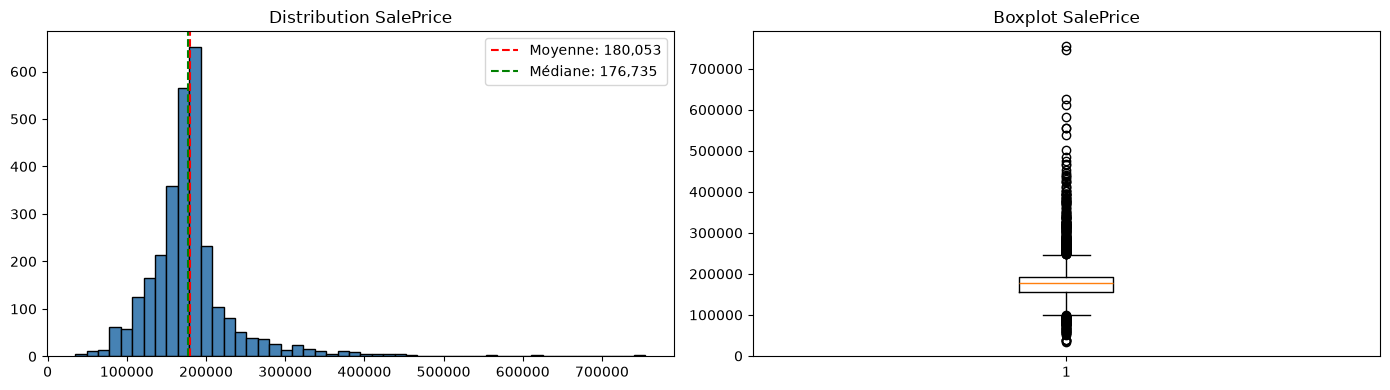

Skewness : 2.549


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Médiane: {df["SalePrice"].median():,.0f}')
axes[0].set_title('Distribution SalePrice'); axes[0].legend()
axes[1].boxplot(df['SalePrice'], vert=True); axes[1].set_title('Boxplot SalePrice')
plt.tight_layout(); plt.show()
print(f"Skewness : {df['SalePrice'].skew():.3f}")

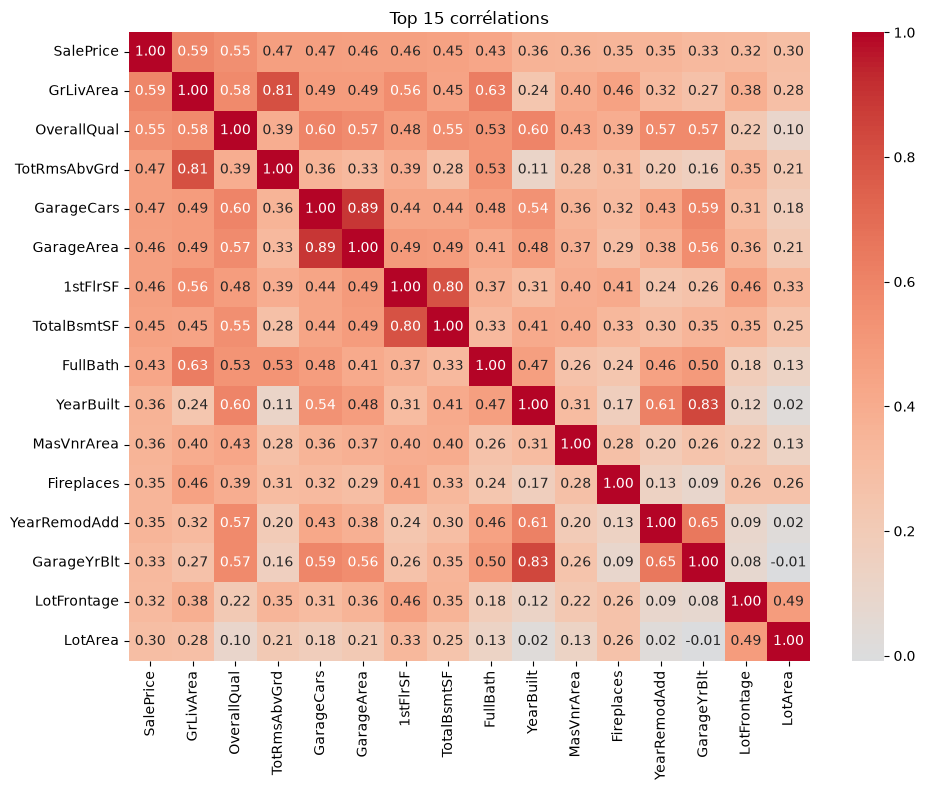

SalePrice      1.00
GrLivArea      0.59
OverallQual    0.55
TotRmsAbvGrd   0.47
GarageCars     0.47
GarageArea     0.46
Name: SalePrice, dtype: float64


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()['SalePrice'].sort_values(ascending=False)
top15 = corr.head(16).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top15].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Top 15 corrélations'); plt.tight_layout(); plt.show()
print(corr.head(6))

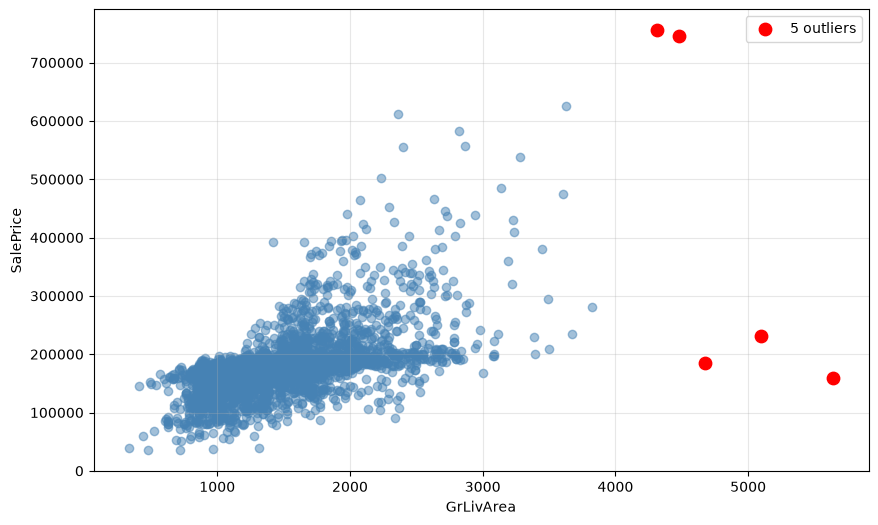

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue')
mask = df['GrLivArea'] > 4000
plt.scatter(df.loc[mask, 'GrLivArea'], df.loc[mask, 'SalePrice'], color='red', s=80, label=f'{mask.sum()} outliers')
plt.xlabel('GrLivArea'); plt.ylabel('SalePrice'); plt.legend(); plt.grid(alpha=0.3); plt.show()

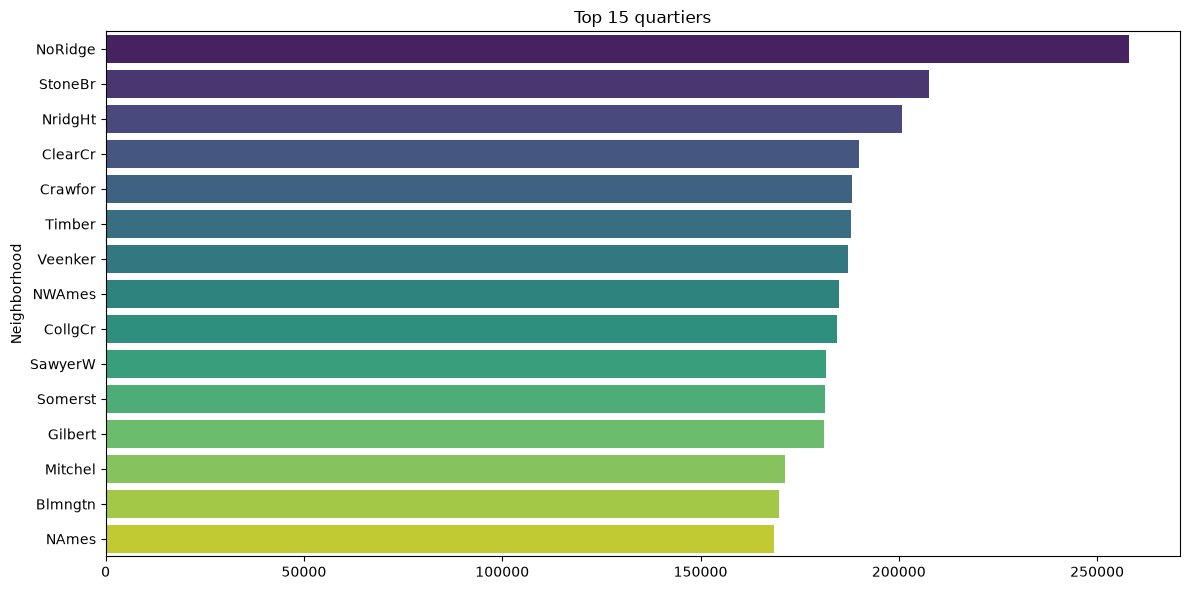

Neighborhood
NoRidge   258,000.00
StoneBr   207,500.00
NridgHt   200,685.04
ClearCr   190,027.32
Crawfor   188,206.28
Name: SalePrice, dtype: float64


In [8]:
top_neigh = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_neigh.values, y=top_neigh.index, palette='viridis')
plt.title('Top 15 quartiers'); plt.tight_layout(); plt.show()
print(top_neigh.head())
